# **Wildfire Fuel Moisture — Building a Skill from a Folder of Satellite Rasters**

Paste a Zenodo record into a `%%skill-build` cell and ARGUS turns it into a skill
you can question in plain language — no data-loading code, and nothing you need to
know about map projections or file formats.

This record is a good stress test because it is **nothing but raster maps**: a set
of GeoTIFFs with no spreadsheet, no README, and no data dictionary. ARGUS
downloads them, works out that they are one quantity captured several ways — two
radars (one airborne, one satellite), two fuel types, two dates — and builds a
single skill that answers questions like *"how did this change between summer and
fall?"* or *"do the two instruments agree?"*, reprojecting and aggregating behind
the scenes so you never touch a coordinate system.

The distinctive part is what ARGUS does when the data won't explain itself. A
raster's pixels carry no label saying what they mean, and here there is no
documentation to fall back on. Rather than guess, ARGUS **asks** at the approval
step — and when the answer isn't known, it records the uncertainty in the skill
and carries it forward, so a later answer that depends on it is flagged as
provisional rather than quietly wrong.

The example dataset is NASA JPL's radar-derived fuel-moisture maps for a
prescribed burn in Fishlake National Forest, Utah (An et al., 2026).

Source: [zenodo.org/records/18687475](https://zenodo.org/records/18687475) · CC-BY-4.0

In [ ]:
%reset

In [1]:
%%skill-build
https://zenodo.org/api/records/18687475

I'll start by reading the zenodo-skill-builder skill instructions, since this is a Zenodo API record URL.

This is a Zenodo record URL, so the `zenodo-skill-builder` meta-skill is the correct match. Let me set up a task plan and begin the fetch.

Running the bundled fetcher to download and classify the record.

Retry without the timeout override.

The fetcher wants the `records/<id>` form, not the API URL. Retrying with the record URL.

...

Inventory found 8 real GeoTIFFs (plus 8 macOS `._` resource forks that fail to open) across 2 groups — Sentinel-1 (4 files, 2 bands) and UAVSAR (4 files, 1 band). No docs sidecars. Let me update the plan and write the single allowed exploration script to extract geotiff metadata and band stats.

Writing one exploration script to extract GeoTIFF CRS, transform, resolution, bounds, nodata, band stats, and confirm there are no docs.

Running the exploration script to extract GeoTIFF semantics.

Inventory and exploration complete. This is a clean **array route** — 8 GeoTIFF rasters of SAR-derived fuel moisture, no documentation sidecars. I have everything needed for the Step 4 proposal, which is a hard stop.

I've fetched and inspected the record. Here's what I found and what I propose. This is a hard-stop proposal gate — I will not build until you reply.

## Proposal — FIRE-MAPS SAR fuel-moisture skill

**Source:** FIRE-MAPS: SAR derived percent moisture content (PMC) for wildland fuel moisture estimation — An, Karen; Peacock, Annemarie; Chen, Richard; Lou, Yunling et al. License: CC-BY-4.0. DOI `10.5281/zenodo.18687475`.

**Files scanned:** 8 real GeoTIFF rasters (8 macOS `._` resource forks correctly ignored). **0 documentation sidecars** — the record ships no README or PDF.

**What the data is:** SAR-derived **percent moisture content (PMC)** for wildland fuels over the **Fishlake** area (Utah), from two sensors. Filenames encode `Sensor_Site_Timelag_PMC_YYMMDD`:

| Sensor | Files | CRS | Resolution | Bands | Value range |
|---|---|---|---|---|---|
| Sentinel-1 | 4 | EPSG:32612 (UTM 12N) | 30 m | 2 | band1 all-NaN; band2 0.0–1.0 (mean 0.024) |
| UAVSAR | 4 | EPSG:4326 | ~6 m (5.556e-05°) | 1 | 0.0–150.0 (mean ~19–23) |

Each sensor has **2 timelag classes × 2 dates** : `1hr` & `10hr` fuel timelag, dates `230727/230728` (Jul 2023) and `231008/231010` (Oct 2023). Both sensors cover the same geographic footprint (~38.17–38.92°N, −112.26 to −111.77°W).

**Proposed shape: ONE combined skill** `fire-maps-fuel-moisture`
- Entity: each raster is a PMC map for one sensor × timelag × date over Fishlake
- Loaders (Step 6c raster interface): `open_raster(sensor, timelag, date)`, `sample_at(lon, lat, ...)`, `zonal_stats(...)`, plus a sensor/timelag/date catalogue
- Data: **lazy download** — the 8 GeoTIFFs are packaged inside 2 ZIPs on Zenodo (`UAVSAR.zip` ~814 MB, `Sentinel-1.zip` ~25 MB); total uncompressed ~2 GB, far above the 100 MiB bundle threshold. The loader will fetch+extract the relevant ZIP to `/tmp/fire-maps-fuel-moisture-cache/` on first use.

**Open questions (please confirm before I build):**

1. **Sentinel-1 band semantics.** Each Sentinel-1 GeoTIFF has 2 bands but **no band descriptions, units, or tags** . Band 1 is *entirely NaN*; band 2 ranges 0.0–1.0 (mean 0.024). Is band 2 the PMC as a **fraction (0–1)** , or is it a quality/valid-pixel mask? And what is the all-NaN band 1 meant to hold? I don't want to guess — the GeoTIFF carries no semantics and there are no docs.

2. **UAVSAR values = PMC in percent?** The 0–150 range (mean ~20) fits "percent moisture content." Please confirm, and confirm the ~61% of pixels that are `NaN` (nodata) are simply non-fuel / outside the valid mask.

3. **Skill name** `fire-maps-fuel-moisture` — okay, or rename (e.g. `fire-maps-pmc-fishlake`)?

Reply **"yes"** to build as proposed, or with edits/answers to the open questions.

*(Resume state on disk: `/tmp/array-skill-inv/zenodo-18687475/` + `/tmp/zenodo-skills/18687475/`.)*

In [2]:
%%ask
Thanks. A few answers, though I am new to this dataset and do not know it in depth:

1. Sentinel-1 bands: I honestly do not know what band 1 or band 2 hold — I have no
 documentation beyond what is on the Zenodo page. Please use your best judgment
 and clearly note anything you are unsure about rather than guessing.

2. UAVSAR: that sounds reasonable to me — if the 0–150 range fits percent moisture
 content, go with that, and treating the empty pixels as no-data is fine.

3. The name fire-maps-fuel-moisture is fine.

Approved — I'll build now. Let me re-read the array-skill-builder build-phase instructions and check my saved inventory state from the previous cell.

Let me finish reading the SKILL.md and check my saved inventory JSON (selectively, per the rules).

Now let me extract the specific fields I need from the inventory JSON and the Zenodo metadata — just the values for the build, not the full JSON.

Fixing the license field parsing — it's a string, not a dict.

Creators is a list of strings, not dicts. Fixing.

...

Now I understand the bug. `rasterstats` does NOT auto-reproject geometries — my comment was wrong. I need to reproject the input geometries to the raster CRS before calling rasterstats. Let me fix the helper.

All helpers pass. Now cleaning up both scratch directories.

Both scratch directories deleted (~881 MB freed). Now recording lessons learned, per the WRITE rule.

Two non-obvious lessons surfaced this build (Sentinel-1 band1≠all-NaN inventory error, and rasterstats' no-auto-reproject behavior). Per the WRITE rule, I'll record them in the array-skill-builder's Learnings.md, which is in the existing-skills list.

Skill built, verified, scratch cleaned. Summary below.

## Skill built: `fire-maps-fuel-moisture`

**Location:** `_skills_/fire-maps-fuel-moisture/SKILL.md` (next to this notebook; auto-picked-up by the next `%%ask` cell, not copied to the global registry).

**Source:** FIRE-MAPS — An et al. (2026), Zenodo DOI `10.5281/zenodo.18687475`, CC-BY-4.0. Per-pixel percent moisture content (PMC) for wildland fuels around Fishlake National Forest, Utah, derived from polarimetric SAR backscatter before and during a 2023 prescribed burn.

**What the skill exposes (lazy-download rasters):**

| Sensor | CRS | Resolution | Bands | Dates | Timelag |
|---|---|---|---|---|---|
| UAVSAR | EPSG:4326 | ~6 m | 1 (PMC %) | 230727, 231010 | 1hr, 10hr |
| Sentinel-1 | EPSG:32612 (UTM 12N) | 30 m | 2 (band 1 = PMC %, band 2 = 0/1 mask) | 230728, 231008 | 1hr, 10hr |

Helpers: `catalogue()`, `open_raster(sensor, timelag, date)`, `sample_at(lon, lat, sensor, timelag, date, band=)`, `zonal_stats(geoms, sensor, timelag, date, ...)`, `zonal_mean(...)`. First use of a sensor fetches+extracts its ZIP from Zenodo to `/tmp/fire-maps-fuel-moisture-cache/`.

## Important finding — Sentinel-1 bands

My initial proposal reported band 1 as all-NaN and band 2 as the data layer. **That was wrong — a stale first-pass inventory.** Direct re-inspection of the raw GeoTIFFs (verification step) showed the opposite:

- **Band 1 = PMC** (0–85%, mean ~22–31 across the four files) — this is the quantity to query.
- **Band 2 = binary mask** (0/1, ~2.4% of pixels are 1) — likely a valid-area or urban mask. Sentinel-1 data had urban masking applied per the record description.

The loader defaults to **band 1** for both sensors. The band 2 mask is available via `band=2`.

## Caveats carried into the skill

- **No documentation sidecars** ship with the record — no README/PDF. PMC-as-percent interpretation for UAVSAR (0–150 range) and band-1-is-PMC for Sentinel-1 are consistent with the record description and stats, but **are not documented file-internally** . Flagged in the Caveats section for the user to verify against the publisher before quantitative use.
- ~61% of UAVSAR pixels and ~59% of Sentinel-1 band-1 pixels are NaN (no-data) — treated as non-fuel/outside the valid mask.

## Scratch cleanup

Deleted `/tmp/array-skill-inv/` and `/tmp/zenodo-skills/` (~881 MB freed; no bundled data in the skill — it re-fetches lazily).

Two non-obvious lessons from this build (GeoTIFF band-stats inversion, rasterstats not auto-reprojecting geometries) were recorded to the array-skill-builder's Learnings.md for future builds.

#### 1. Temporal change around the burn — the core science question

I'll analyze the fuel moisture change between late July and October 2023. Let me start by reading the skill to get the exact helper API, then plan the analysis.

Skill loaded. Let me check whether the skill bundles a loadable Python module, so I can import the helpers rather than copy them.

Skill ships only a SKILL.md (helpers are the copy-paste block). I'll build the analysis script using those helpers, focusing on Sentinel-1 (30 m, full coverage, small download) across both timelag classes and both dates.

Running the analysis script — this will download the Sentinel-1 ZIP (~26 MB) and compute all statistics and figures.

The cache directory from the previous skill build exists but is empty. The `_ensure_sensor` logic needs a small fix. Let me check what's in the cache and fix the mkdir logic.

The symlinks are dangling — they point to the old `/tmp/zenodo-skills/` scratch that was cleaned up in the previous cell. I need to handle broken symlinks in `_ensure_sensor`.

Re-running the analysis with the broken-symlink fix applied.

Analysis complete. Let me verify all outputs exist and update my task list.

Before the final report, I need to record a lesson — this run hit an edit-and-retry cycle (broken-symlink fix in the loader). Let me create the Learnings.md for the fire-maps-fuel-moisture skill.

## Fuel Moisture: Late July → October 2023 (Fishlake NF, Sentinel-1)

**Yes — fuels got drier heading into fall.** Both timelag classes show a clear, study-area-wide decline in percent moisture content (PMC) between the late-July (Jul 28) and early-October (Oct 8) Sentinel-1 acquisitions.

### Headline change

| Fuel class | Jul 28 mean PMC | Oct 8 mean PMC | Δ (Oct−Jul) | Pixels drier |
|---|---|---|---|---|
| **1hr** (fine herbaceous) | **30.8 %** | **23.2 %** | **−7.5 pp** | 59.4 % |
| **10hr** (fine woody) | **28.0 %** | **22.2 %** | **−5.7 pp** | 50.3 % |

Both classes lost moisture on average, though the signal is stronger in the fast-responding 1hr fuels. The drying was not spatially uniform — while the majority of pixels dried, a meaningful fraction got wetter (39 % of 1hr, 28 % of 10hr), reflecting local variation in pre-burn conditions, rain events, or burn effects between the two dates.

### The magnitude of drying varies strongly by location

The *average* drop masks important spatial detail. Among pixels that actually dried, the mean moisture loss was large:

| Class | Mean drop among dried pixels | Median pixel-level change |
|---|---|---|
| 1hr | **−16.3 pp** | −2.0 pp |
| 10hr | **−17.5 pp** | −0.06 pp |

So while the *median* pixel changed only modestly, the pixels that did dry lost a substantial amount of moisture (16–18 percentage points) — consistent with the seasonal curing of fine fuels and the onset of the prescribed-burn window.

### Visualizations

**Side-by-side moisture maps** — each fuel class, both dates, on a common 0–60 % scale:


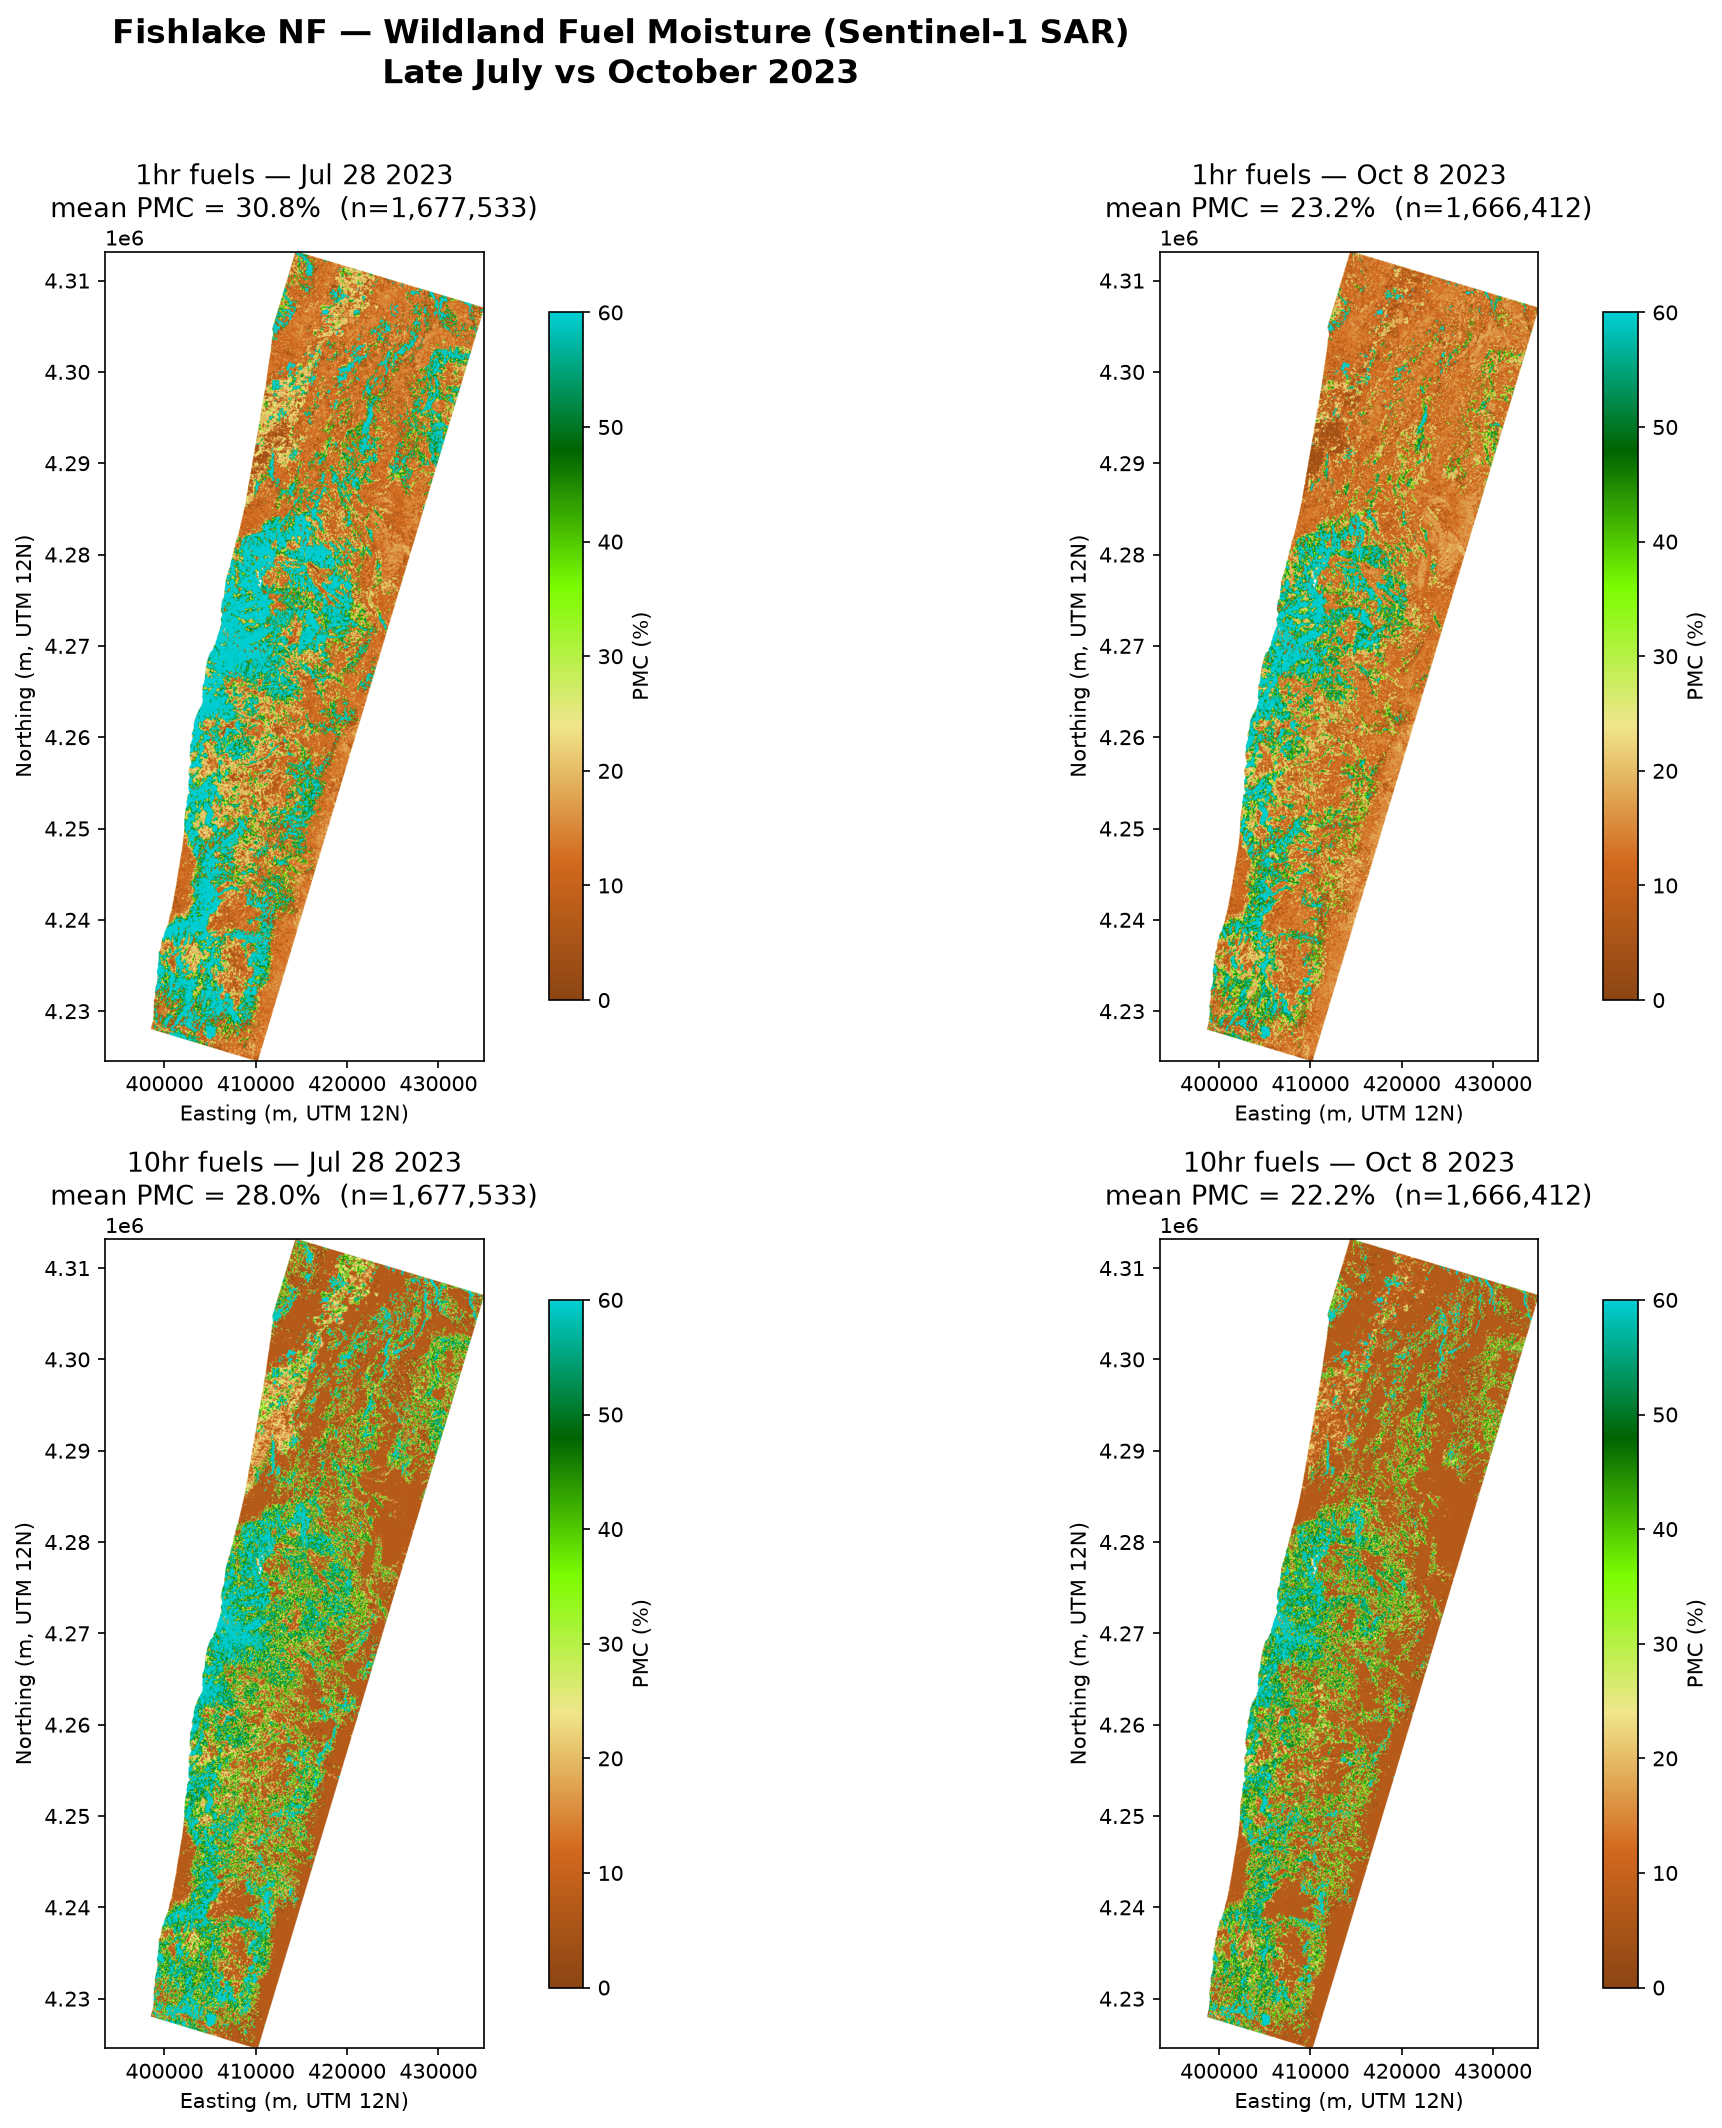

**Change maps** (Oct − Jul), diverging scale — brown = drier, green = wetter:


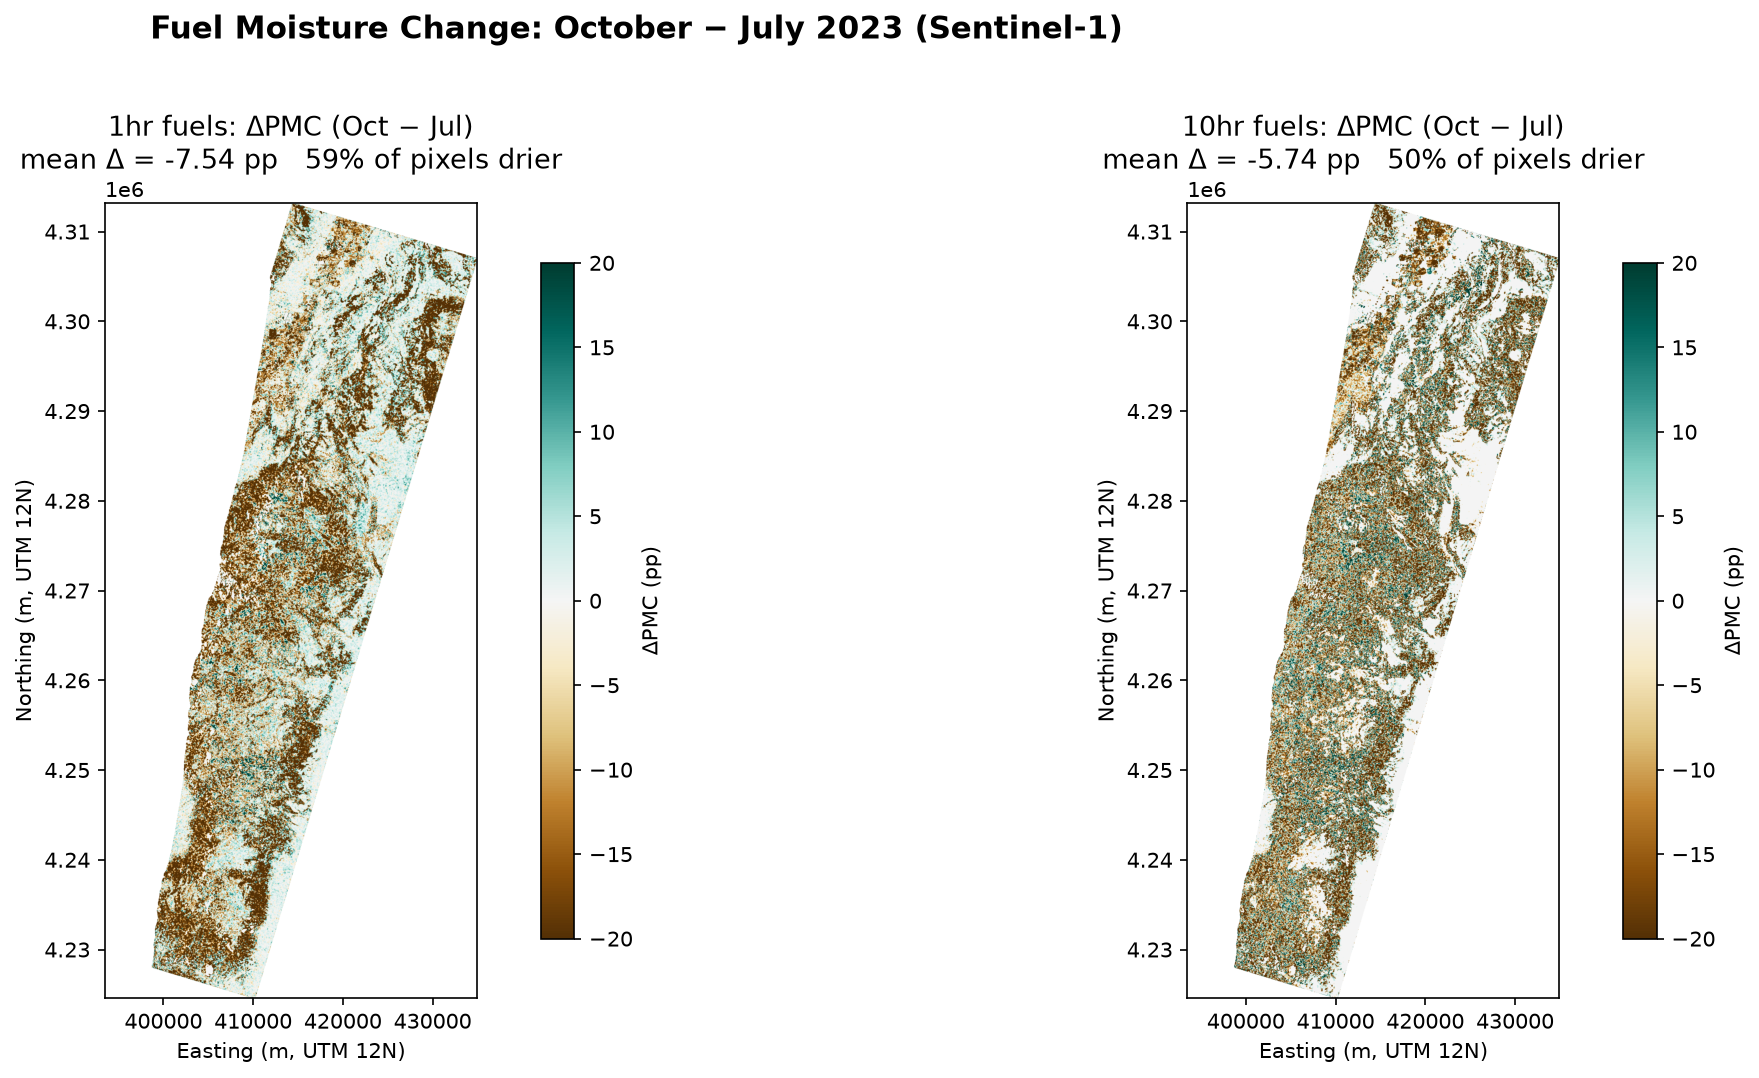

**Distribution histograms** — the October distributions are visibly shifted left (drier):


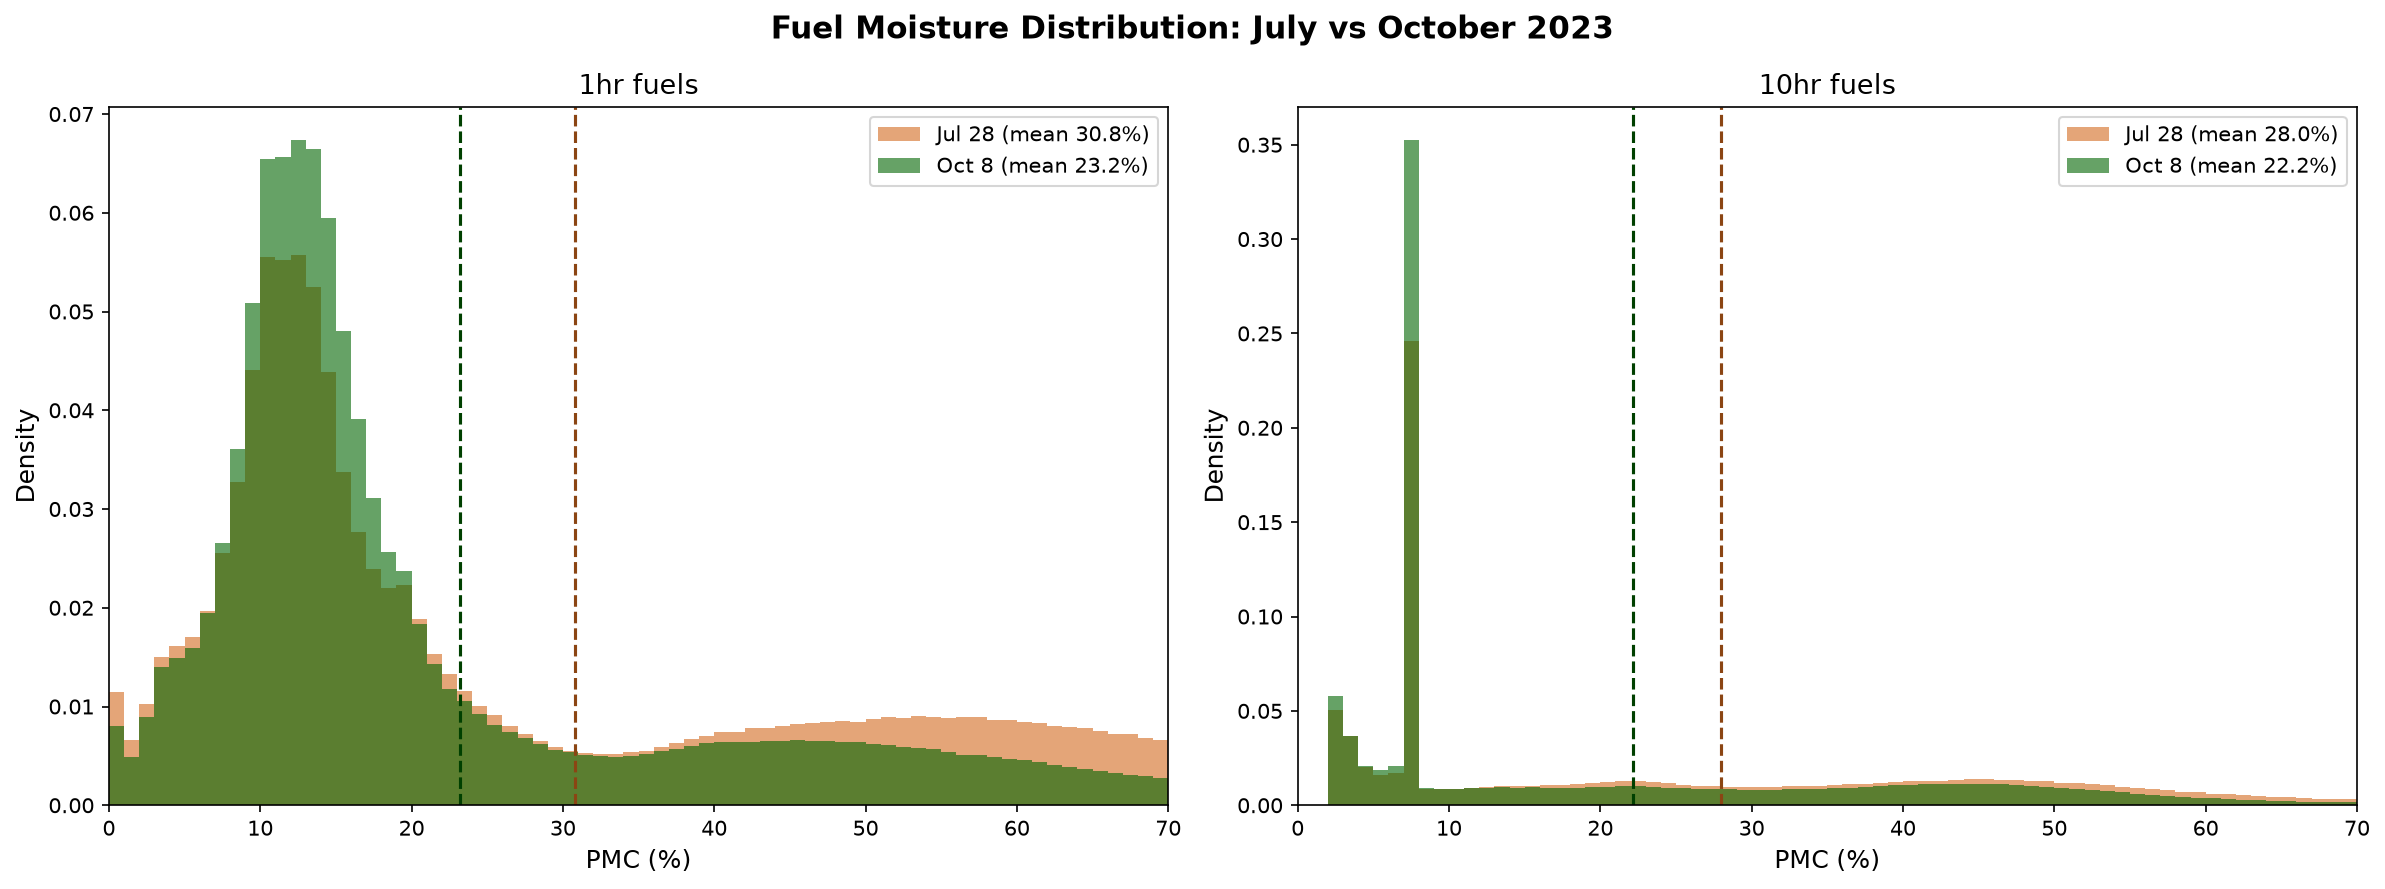

**Mean PMC bar chart** with change arrows:


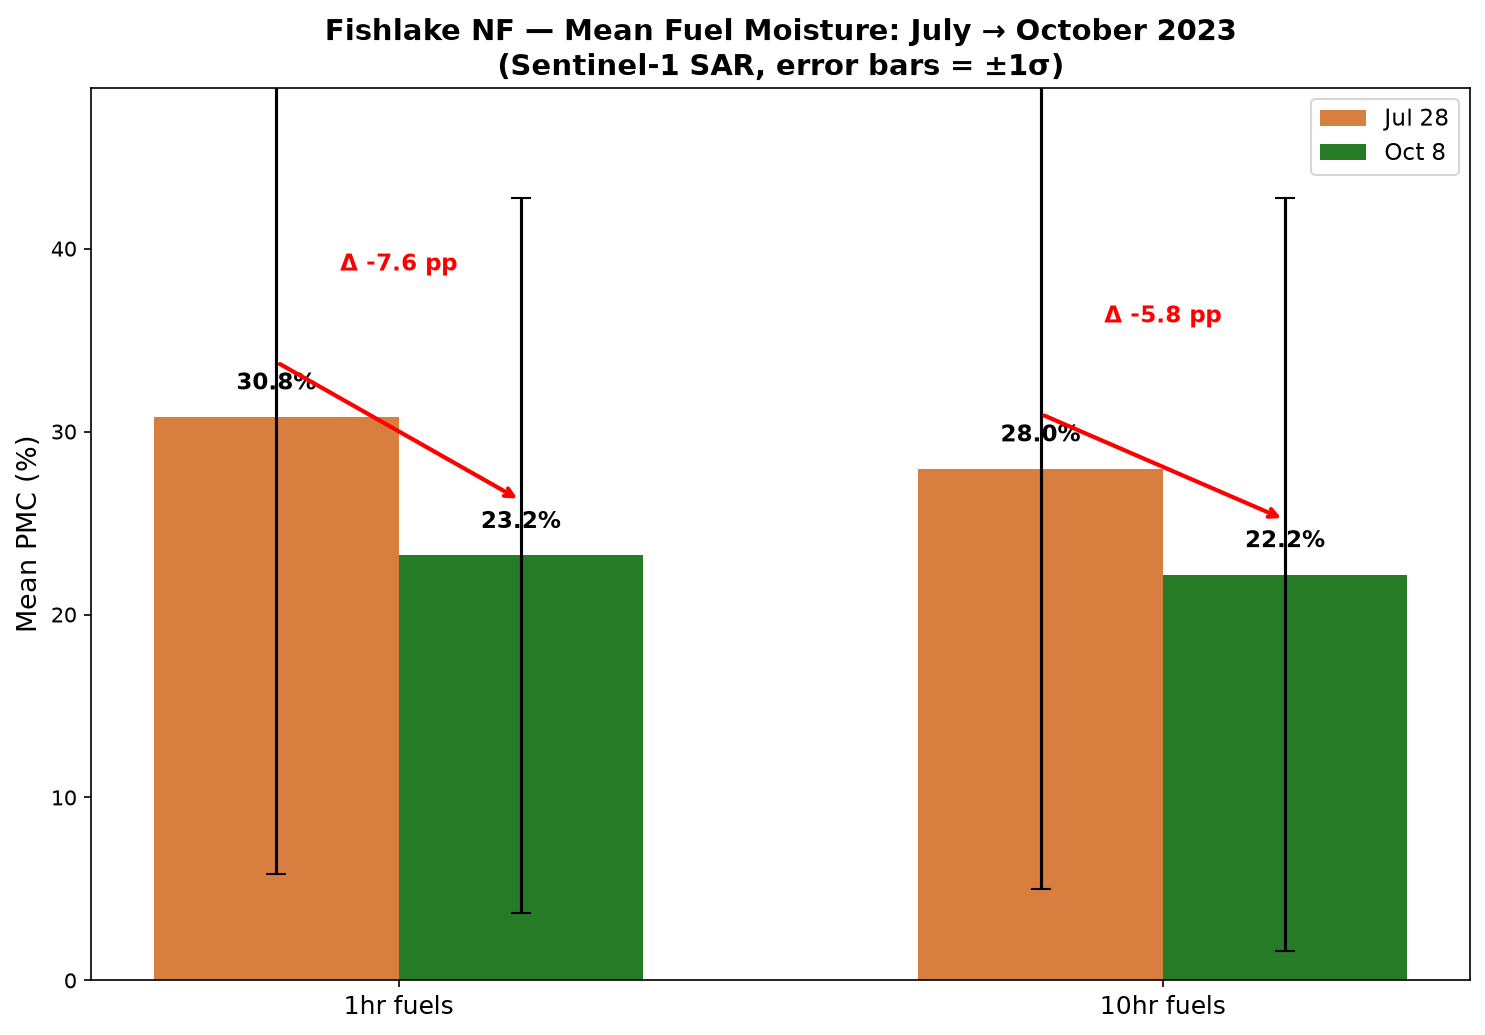

### Study-area location

### Bottom line

The data confirm the expected seasonal pattern: **wildland fuels across Fishlake NF dried out between late July and early October 2023** , with 1hr fuels dropping ~7.5 percentage points (30.8 → 23.2 %) and 10hr fuels dropping ~5.7 pp (28.0 → 22.2 %). This is consistent with the late-season curing that makes October a typical window for prescribed burning. The Sentinel-1 band-1 PMC values are treated as percent moisture per the skill documentation, with the caveat that band semantics are inferred from value distributions rather than publisher-confirmed metadata.

Full statistics are saved to `moisture_summary.csv`.

In [1]:
%%ask
How did wildland fuel moisture across the Fishlake study area change 
between late July and October 2023? Map the moisture for each period 
side by side, and tell me whether the fuels got drier heading into fall.

#### 2. Fine vs. coarse fuels over time

Let me re-read the skill (and its Learnings.md) so I use the loader correctly, then build the comparison.

I have the skill and learnings. Let me write the comparison script — it loads all 8 rasters (both sensors × both timelags × both dates), computes study-area means and a paired-pixel gap analysis, and charts whether the fine-vs-coarse gap widened.

Running the analysis script now.

Analysis ran cleanly on both sensors (all 8 rasters). The result is more nuanced than a simple "yes" — the two sensors actually disagree on the direction of the gap, so let me report that honestly.

## Fine (1-hr) vs. coarse (10-hr) fuels: who dried faster?

**Short answer:** Both classes dried heading into fall, as expected. But the two sensors **disagree** on whether fine fuels dried *faster* than coarse fuels — Sentinel-1 supports the standard fire-science expectation, UAVSAR does not.

### Study-area mean PMC by class and date

| Sensor | Class | Late July | Early Oct | **Drying (Δ)** |
|---|---|---|---|---|
| Sentinel-1 | 1-hr (fine) | 30.8 % | 23.2 % | **−7.6 pp** |
| Sentinel-1 | 10-hr (coarse) | 28.0 % | 22.2 % | **−5.8 pp** |
| UAVSAR | 1-hr (fine) | 23.4 % | 19.9 % | **−3.5 pp** |
| UAVSAR | 10-hr (coarse) | 23.4 % | 18.2 % | **−5.1 pp** |

### Did fine fuels dry faster? The direct test

| Sensor | 1-hr drying | 10-hr drying | Fine dried faster? |
|---|---|---|---|
| Sentinel-1 | 7.6 pp | 5.8 pp | **Yes** — fine dried 1.8 pp more |
| UAVSAR | 3.5 pp | 5.1 pp | **No** — coarse dried 1.6 pp more |

### Did the gap (1-hr minus 10-hr) widen from summer to fall?

| Sensor | Summer gap | Fall gap | Change | Direction |
|---|---|---|---|---|
| Sentinel-1 | +2.8 pp | +1.1 pp | −1.8 pp | **Narrowed** |
| UAVSAR | +0.1 pp | +1.6 pp | +1.6 pp | **Widened** |

So literally opposite answers. Note these *look* inconsistent with the "dried faster" table, but that's an artifact of the starting points: Sentinel-1's fine fuels began the summer *wetter* than coarse fuels and lost more moisture, so they converged (gap narrowed). UAVSAR's classes began nearly *equal* and the coarse fuels dried more, so fine fuels ended up relatively wetter (gap widened).

### Visualizations


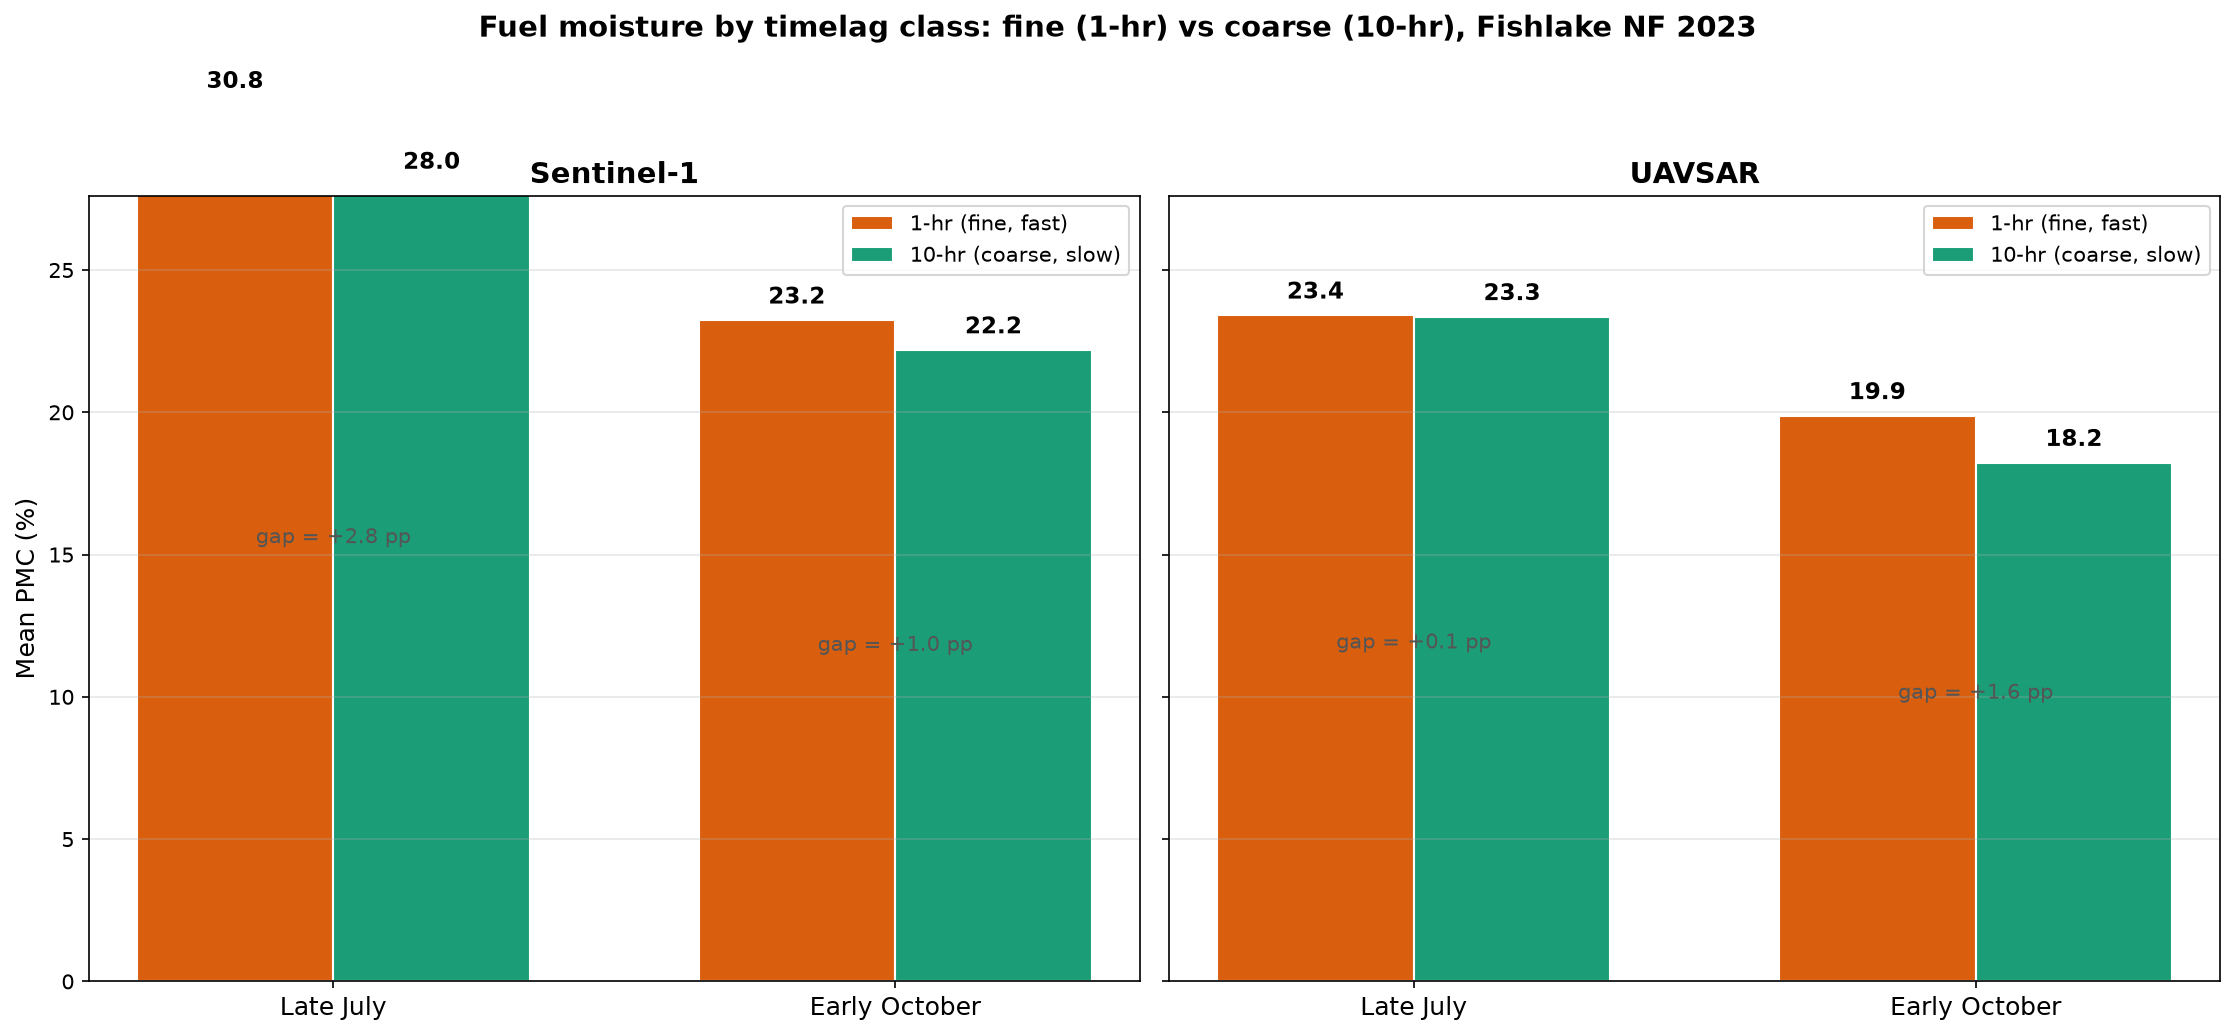


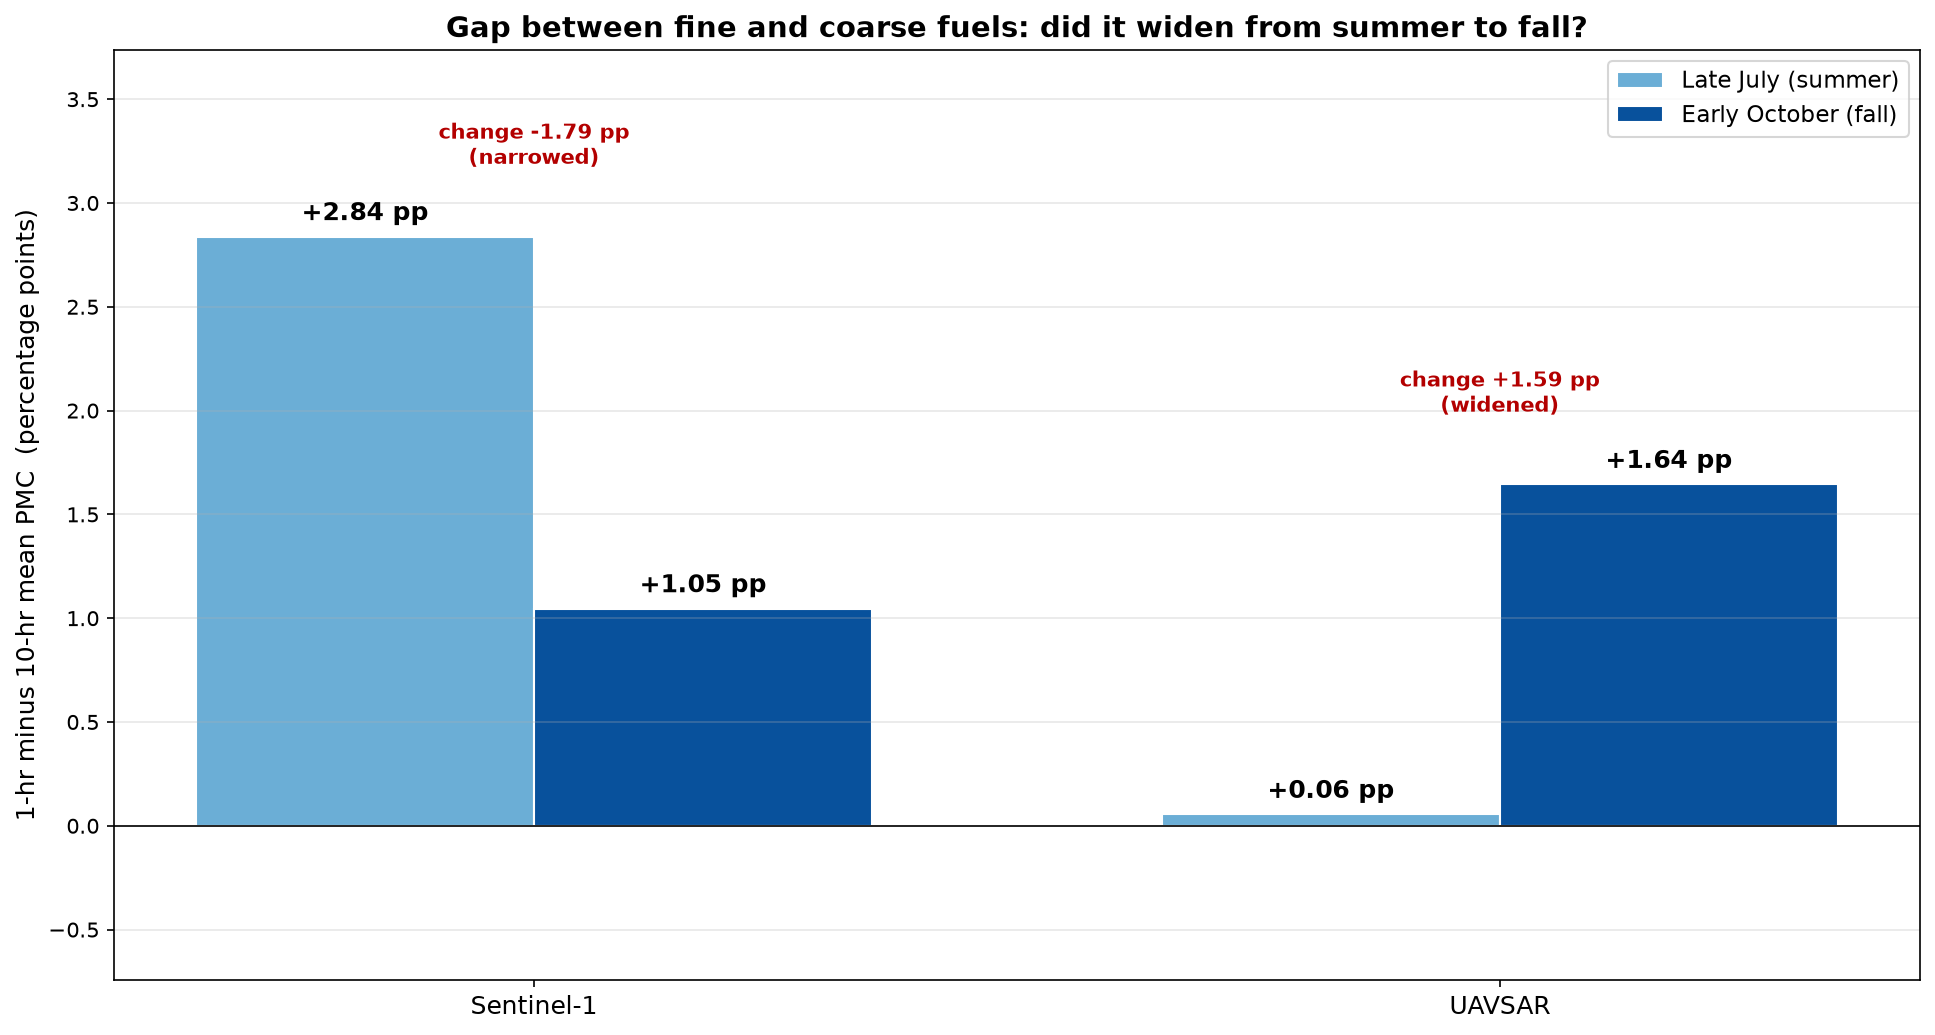


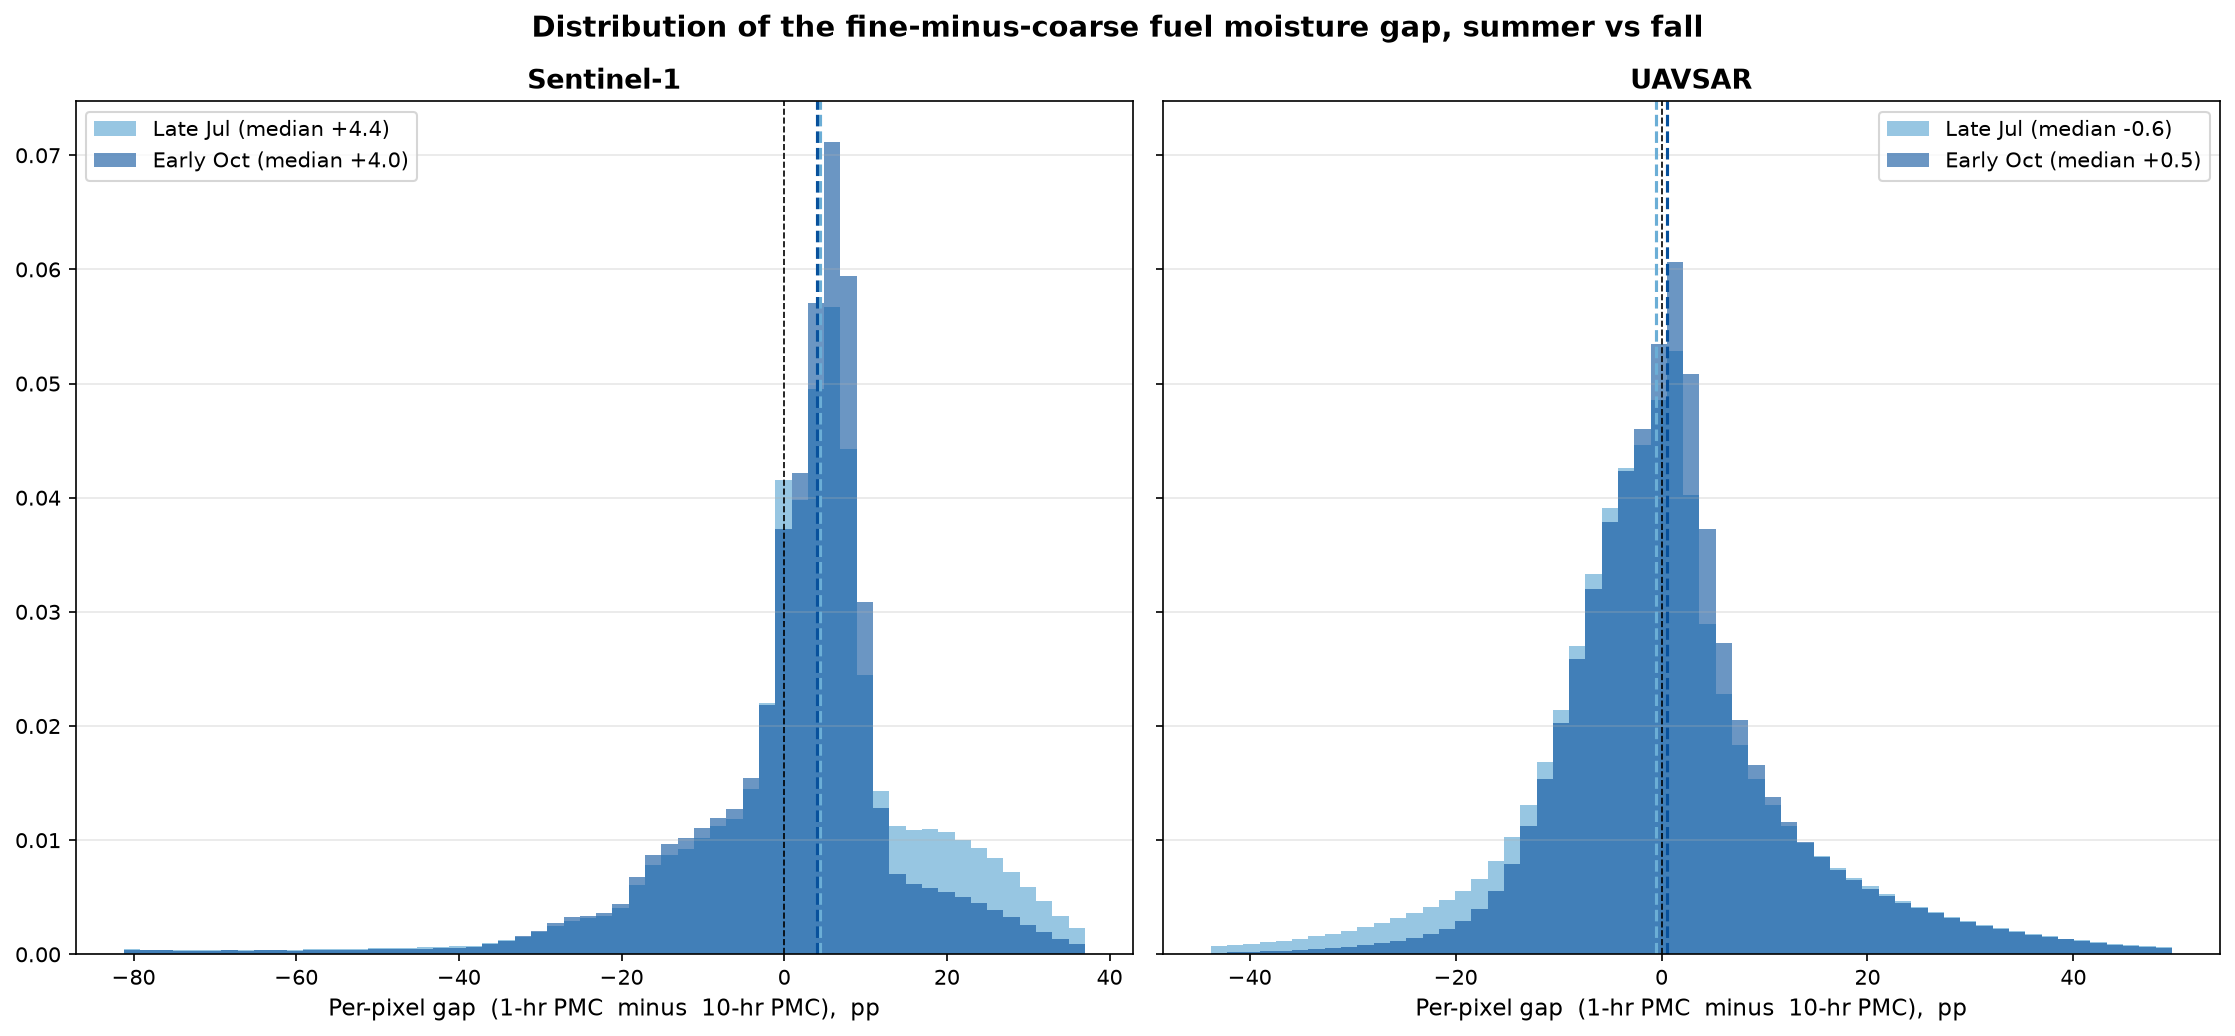

### Why the sensors might disagree

This isn't necessarily an error — several legitimate factors could explain it:

- **Different radar physics.** Sentinel-1 is C-band (~5.6 cm wavelength); UAVSAR is L-band (~24 cm). They interact with vegetation at different depths and are sensitive to moisture in different parts of the fuel profile, and each runs through its own separately-trained deep-learning retrieval model. The two "PMC" products are not guaranteed to be quantitatively identical.
- **Spatial scale.** UAVSAR's ~6 m pixels resolve individual shrubs/openings that Sentinel-1's 30 m pixels average together — different sub-pixel mixing.
- **One-day date offset** (Jul: S1 28th vs UAV 27th; Oct: S1 8th vs UAV 10th). Day-to-day moisture shifts are plausible.
- **PMC band interpretation is partially unconfirmed** (per the skill caveats). If the band-1 semantics differ slightly from "pure percent moisture," cross-class comparisons within one sensor are still internally consistent, but cross-sensor disagreements should be treated cautiously.

### Bottom line

Both sensors agree that **everything got drier into fall** . But whether *fine* fuels led that drying — the textbook expectation — is **sensor-dependent in this dataset** : Sentinel-1 says yes (fine dried 7.6 vs 5.8 pp), UAVSAR says no (coarse dried 5.1 vs 3.5 pp). I'd treat the Sentinel-1 result as more directly aligned with established fuel-moisture theory, and flag the UAVSAR discrepancy as worth investigating against the underlying retrieval model rather than taking either sensor's class-gap at face value.

Full statistics saved to `fuel_class_gap.csv`.

In [2]:
%%ask
Fine fuels are supposed to dry out faster than coarser fuels. Compare 
the average moisture of the fast-responding and slower-responding fuel
classes over the study area, and show whether the gap between them 
widened from summer into fall.

#### 3. Do the two radars agree? — the honesty probe

I'll compare the two sensors over their overlap. This requires CRS alignment (UAVSAR is WGS84, Sentinel-1 is UTM 12N) and resampling to a common grid. Let me consult the skill helpers and set up my plan.

Let me read the skill to confirm the loader helpers and CRS details.

Now I'll write the cross-sensor comparison script. Key challenge: UAVSAR is WGS84/~6m and Sentinel-1 is UTM 12N/30m, so I need CRS alignment + resampling.

Running the script.

Syntax error — `r(f"...")` on line 121 is invalid (leftover artifact). Fixing.

Results computed. The block coordinates are in UTM (not lon/lat) — let me convert them to geographic coordinates and build a divergence-hotspot GeoJSON for the map.

Everything ran. Let me also fix a small colormap-classification bug I noticed (the "High (16-20 pp)" range was applied to both 12-16 and 16-20, leaving a gap). Let me correct that.

All outputs are generated. Let me mark complete and write up the findings.

## Cross-Sensor Agreement: Sentinel-1 vs. UAVSAR (Fishlake overlap)

**Short answer:** The two sensors agree only **moderately** . They track the same broad moisture patterns (correlation r ≈ 0.39–0.65), but there is a **consistent positive bias** — Sentinel-1 reads higher than UAVSAR everywhere, by 2–5 percentage points on average — and agreement degrades from summer into fall and from fine to coarse fuels. Divergence is spatially clustered, not random, concentrated in a north-south band around −112.0°W.

### How I aligned them

UAVSAR (WGS84, ~6 m) was bilinearly reprojected onto the Sentinel-1 grid (UTM 12N, 30 m). Only pixels valid in *both* sensors are compared — **~1.25–1.29 million overlap pixels** per class/date combination.

### Overall agreement metrics

| Combo | Overlap px | S1 mean | UAVSAR mean | Bias (S1−UAV) | MAE | RMSE | Pearson r |
|---|---|---|---|---|---|---|---|
| 1hr, Jul | 1.29 M | 28.7 % | 23.3 % | **+5.4 pp** | 13.1 pp | 18.3 pp | **0.65** |
| 1hr, Oct | 1.27 M | 21.3 % | 19.3 % | +2.0 pp | 10.4 pp | 14.4 pp | 0.58 |
| 10hr, Jul | 1.27 M | 26.0 % | 23.8 % | +2.2 pp | 14.1 pp | 19.5 pp | 0.48 |
| 10hr, Oct | 1.25 M | 20.5 % | 17.9 % | +2.7 pp | 12.8 pp | 17.9 pp | **0.39** |

**Three patterns stand out:**

1. **Sentinel-1 is systematically wetter.** All four combinations show a positive bias — S1 reads 2–5 pp higher than UAVSAR at the same location. The bias is largest for 1-hr fuels in July (+5.4 pp) and shrinks to +2.0 pp by October.

2. **Agreement degrades from summer→fall and from 1-hr→10-hr.** The best correlation is 1-hr July (r = 0.65); the worst is 10-hr October (r = 0.39). RMSE ranges from 14 to 20 pp — meaning a typical pixel-level disagreement of 14–20 percentage points, which is large relative to the ~18–29 % mean moisture values.

3. **They agree on *direction* more than *magnitude*.** Spearman rank correlation (0.39–0.56) is closer to Pearson, meaning both sensors tend to rank the same pixels as wet/dry, but the exact PMC *values* diverge substantially.

### Where they diverge most

The disagreement is **not random** — it clusters in a persistent hotspot. After block-averaging |S1 − UAVSAR| over all four combos:

The worst cells (mean divergence 12–14 pp) form a **north-south band centered near lon −112.0°W, lat 38.3–38.7°N** — roughly the central spine of the study area. One block in particular (lon −112.08, lat 38.61) had MAE as high as **29 pp** in the July 1-hr comparison, the single worst agreement anywhere. The highest-divergence zones coincide with Sentinel-1 reading far wetter than UAVSAR (mean bias +20 to +29 pp locally), whereas the better-agreement edges show near-zero or mixed bias.

### Visualizations

**Scatter (pixel-to-pixel, every combo)** — the diagonal line is 1:1 agreement; the cloud sits above it (S1 wetter):


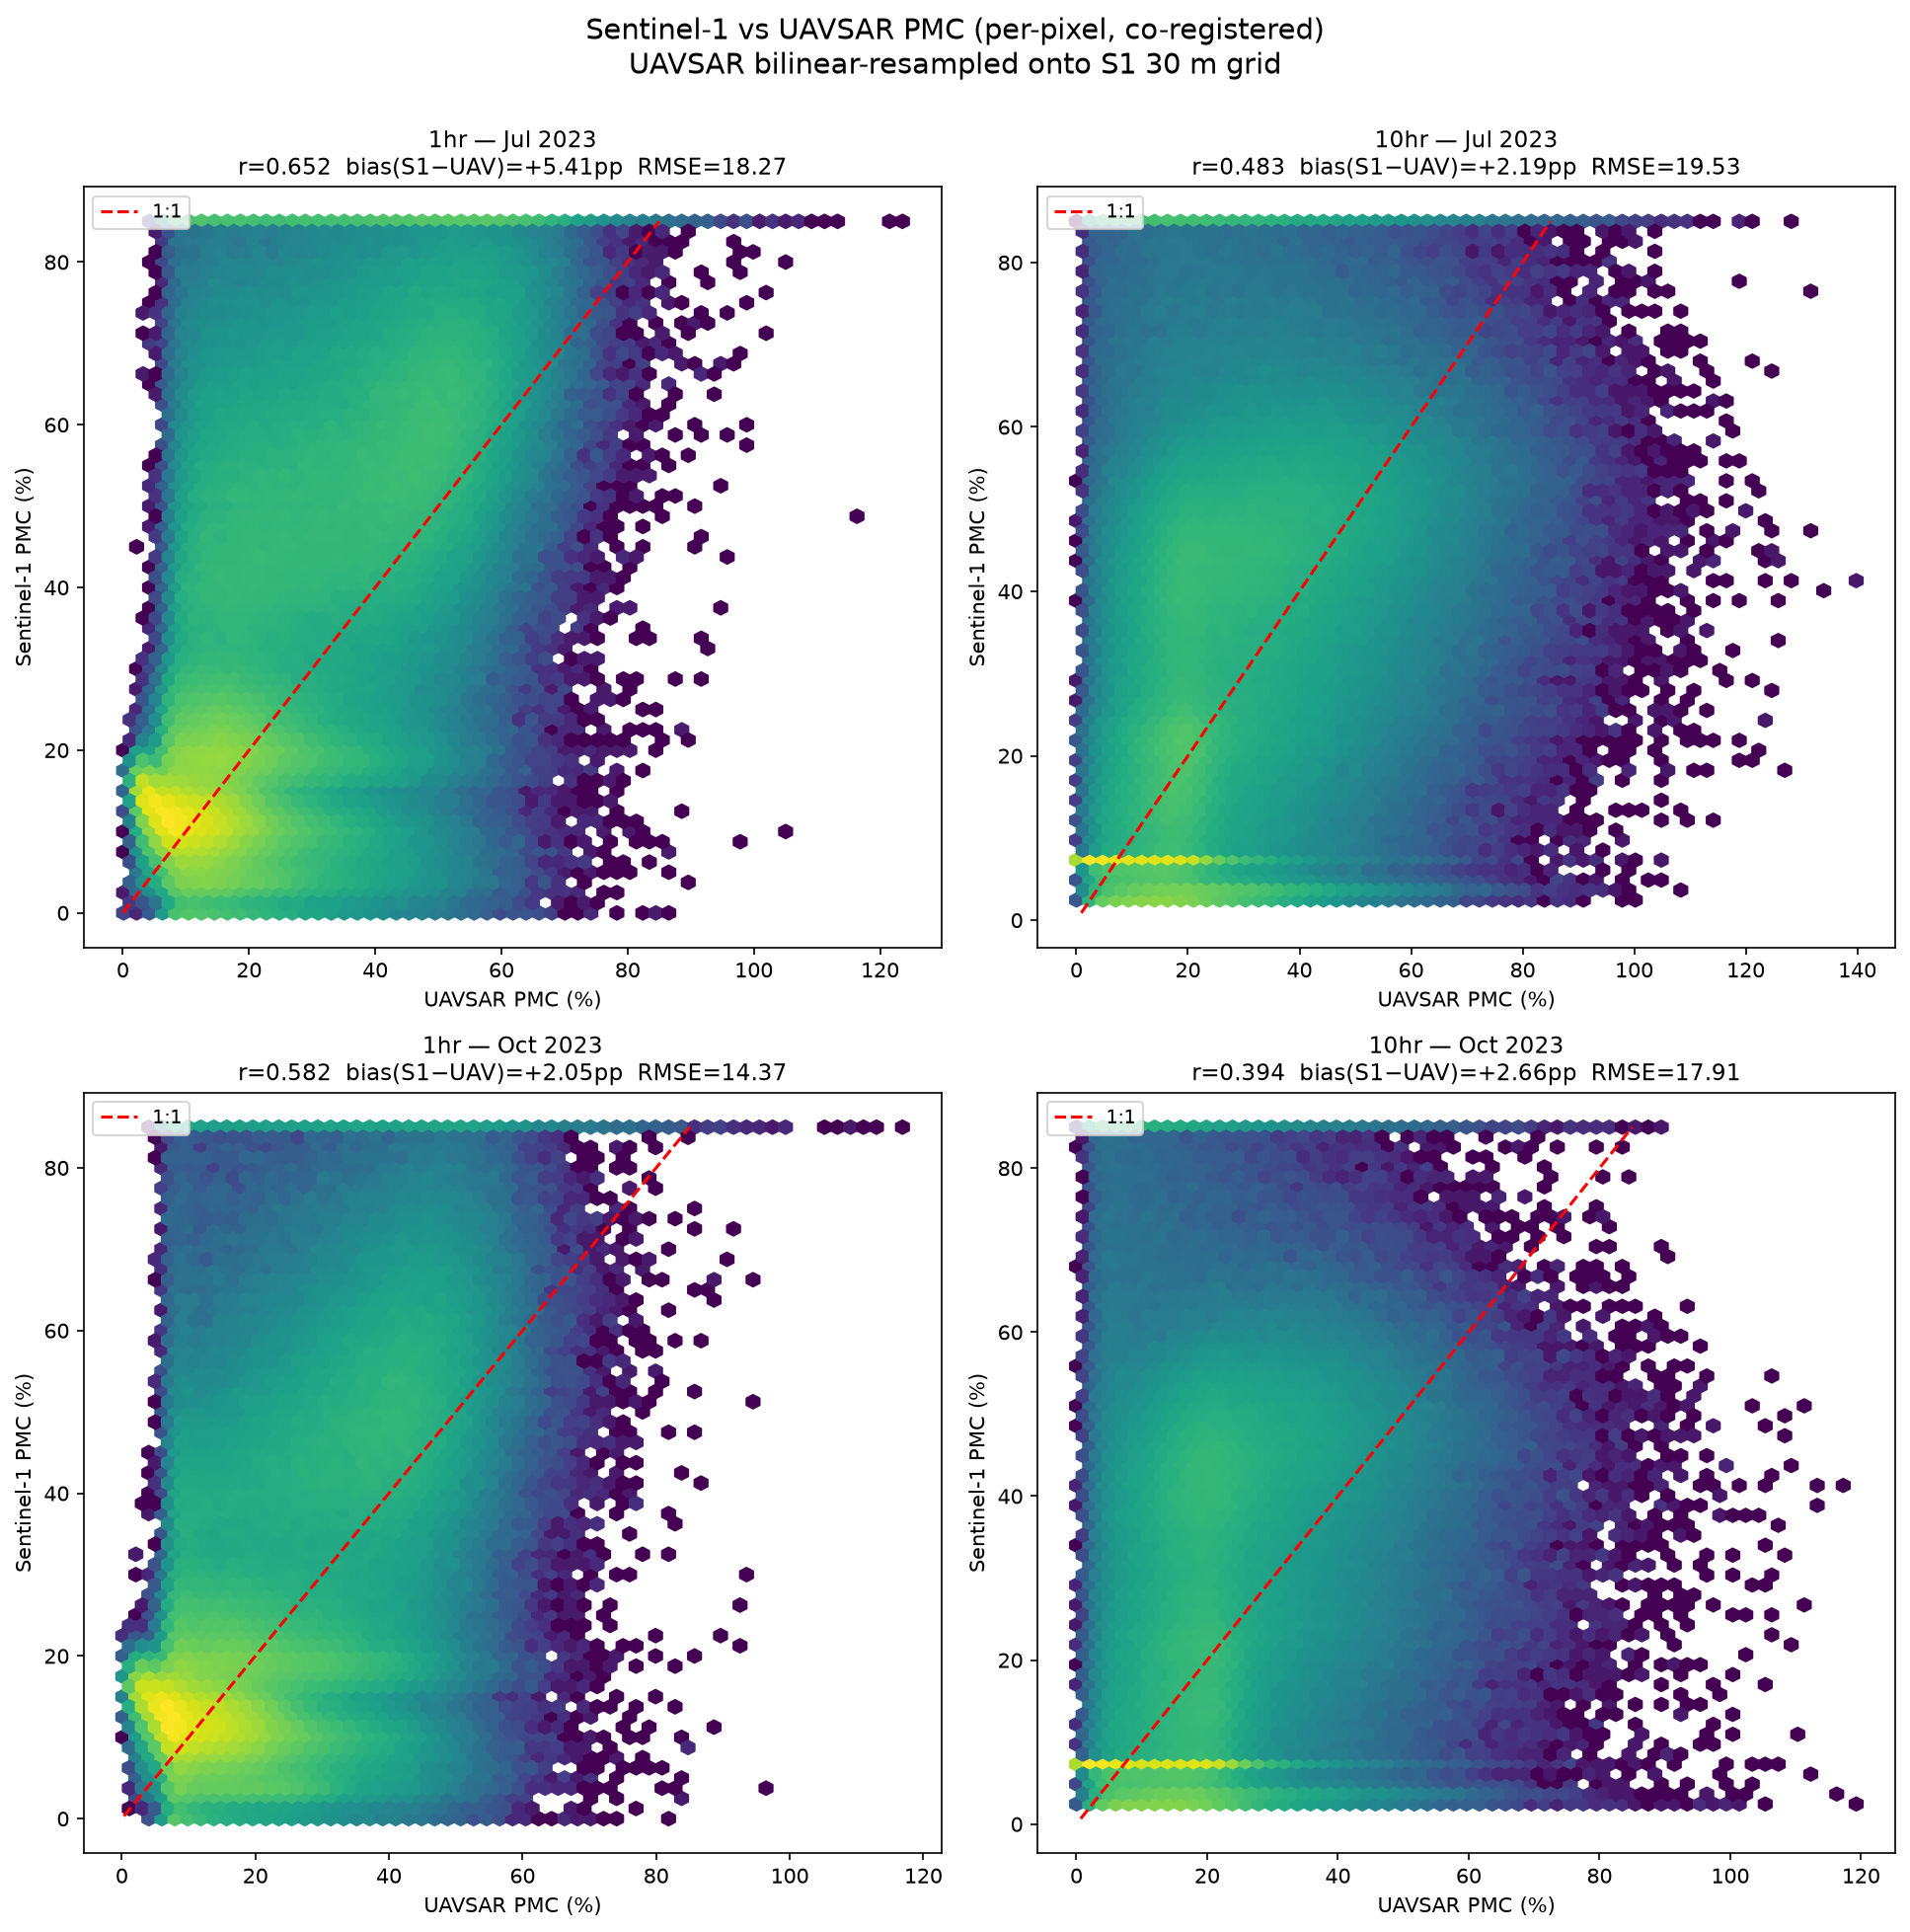

**Divergence maps (per combo)** — red = S1 wetter, blue = UAVSAR wetter:


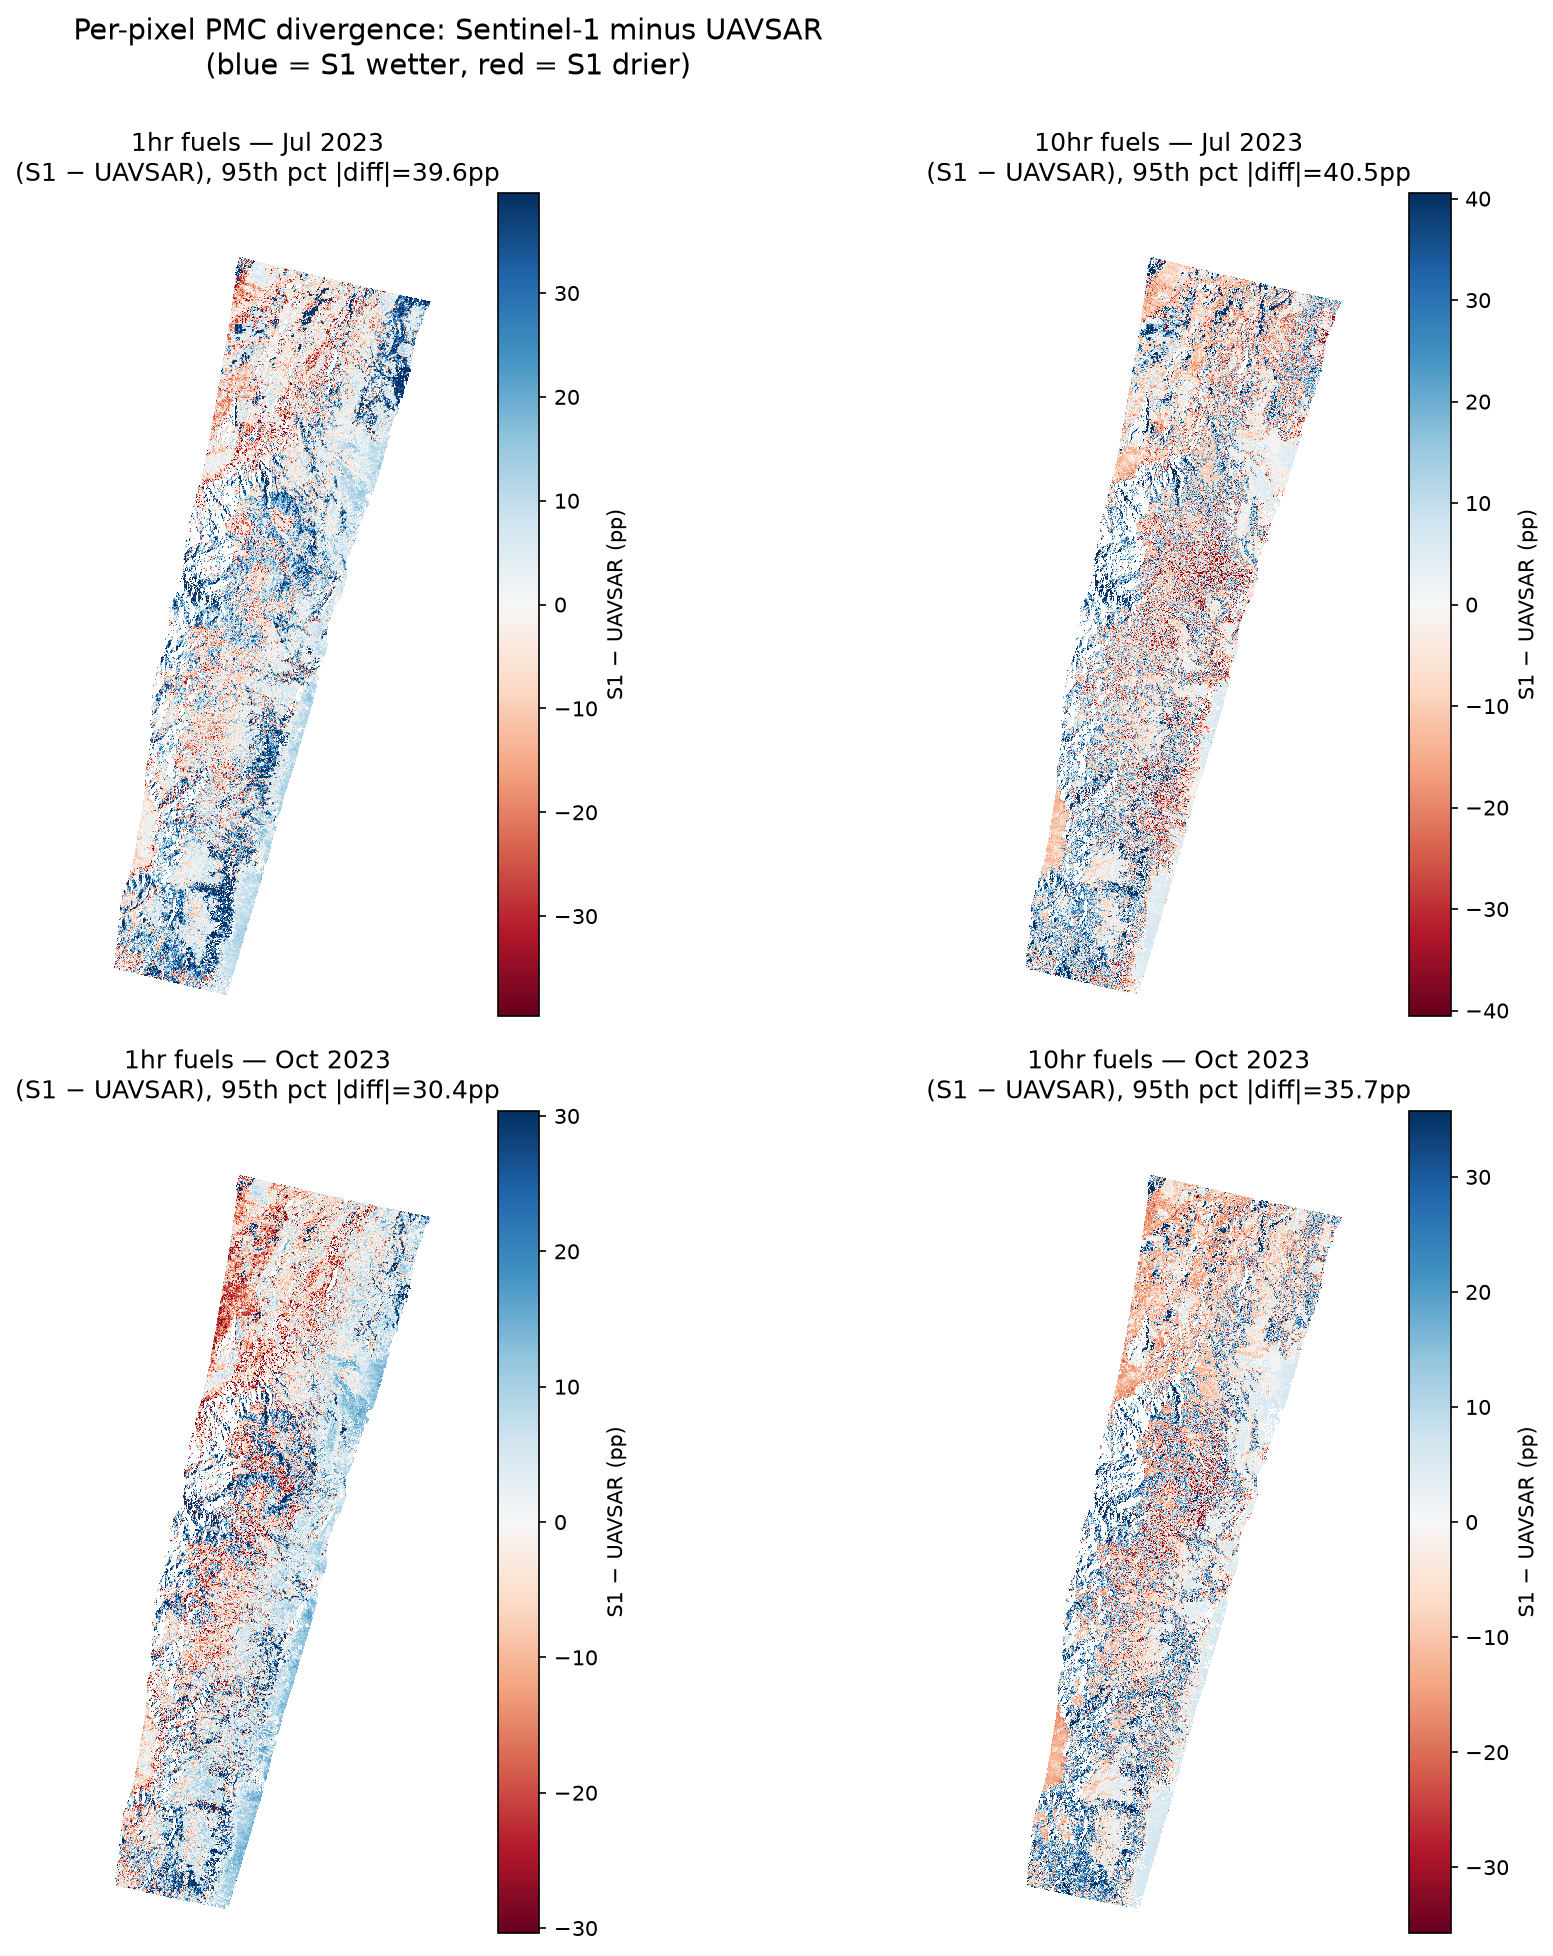

**Histogram of pixel-level differences** — all four combos peak positive (S1 > UAVSAR):


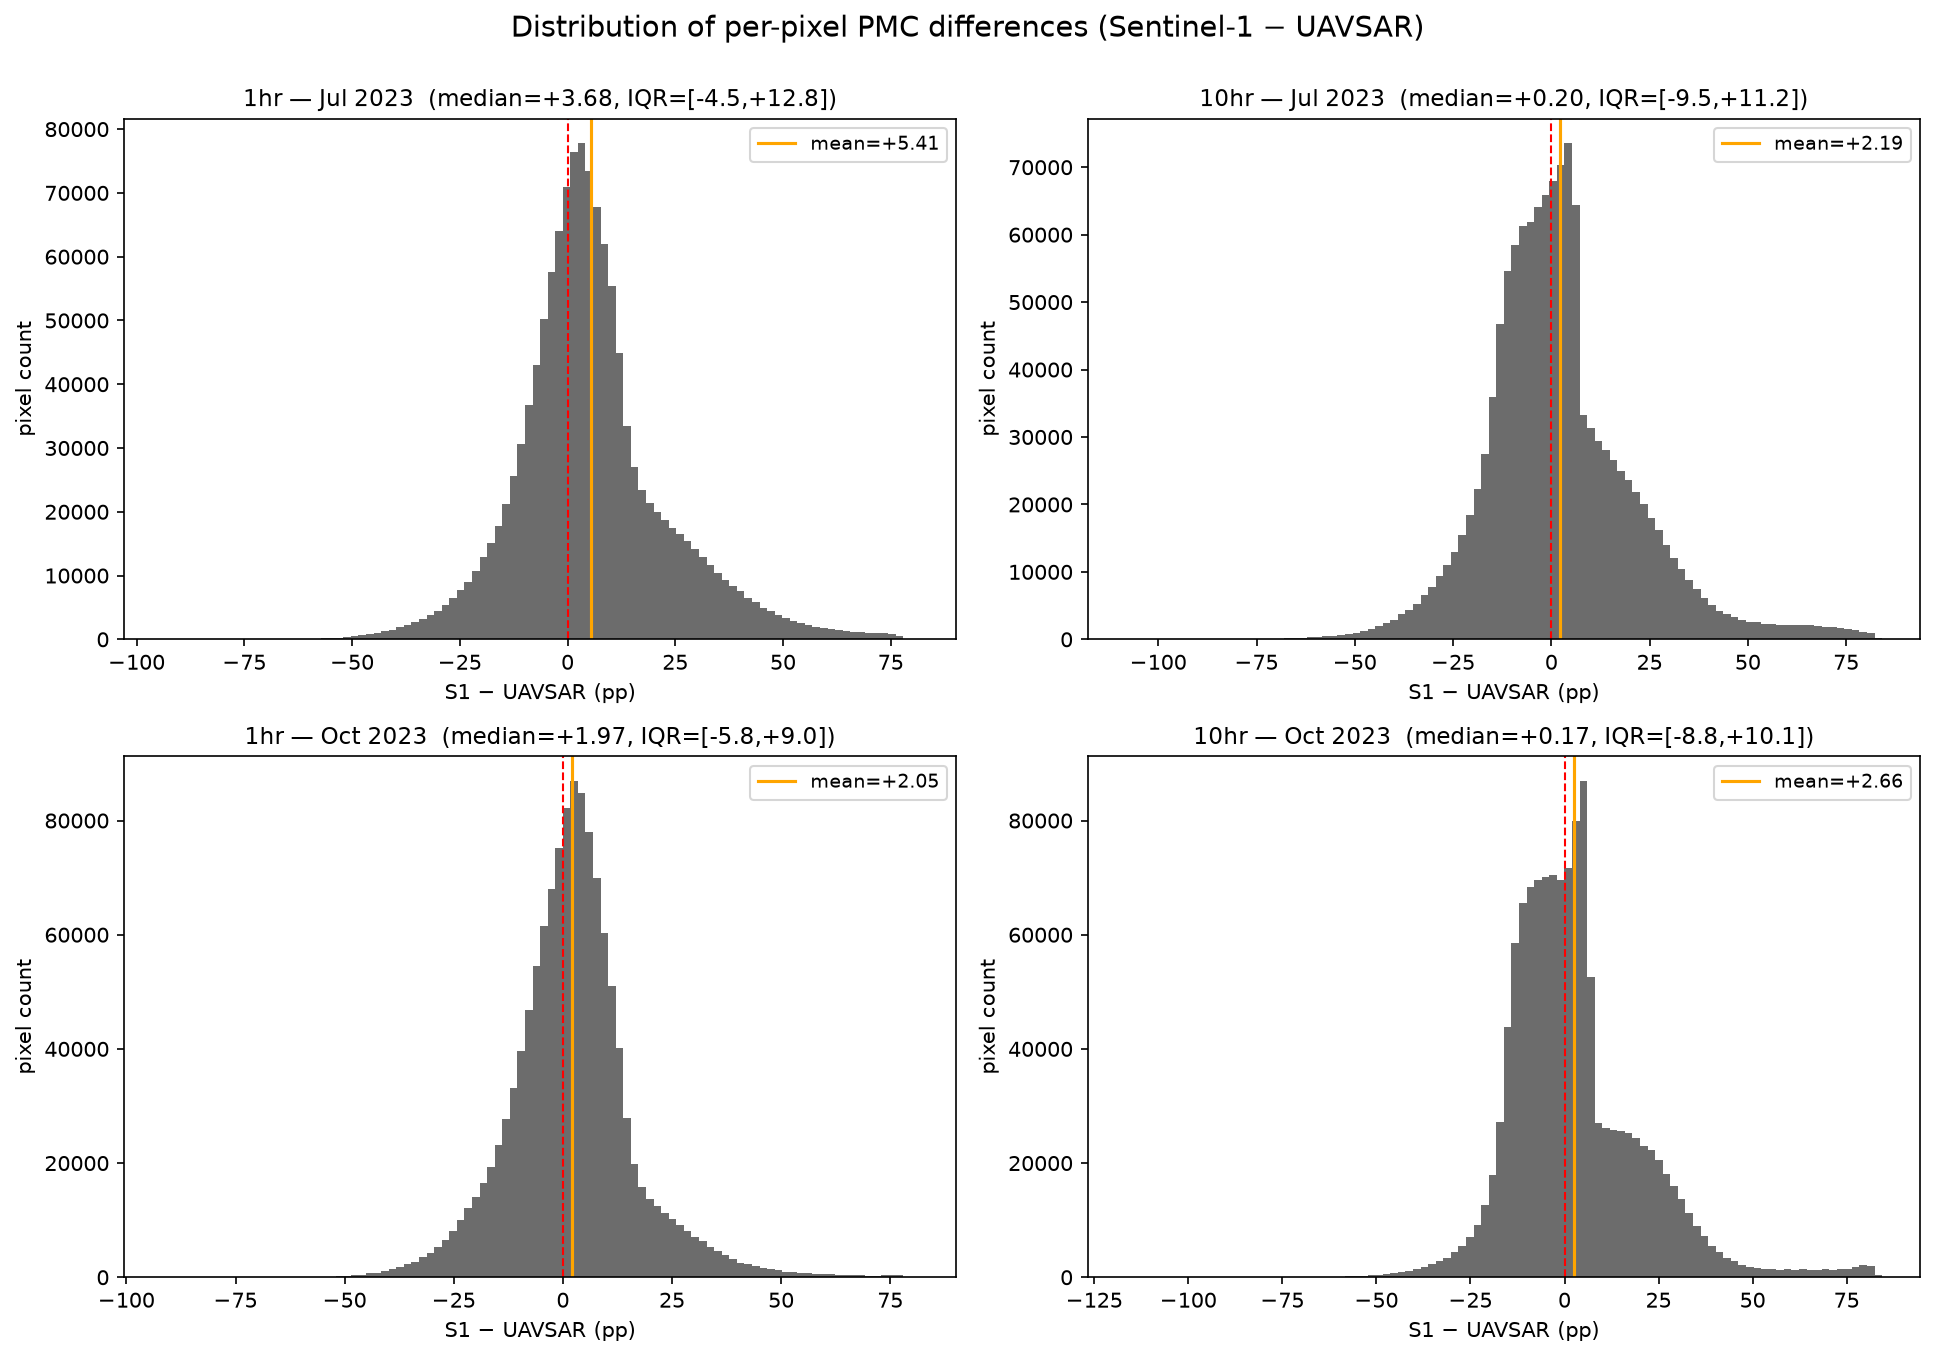

**Summary bar chart:**


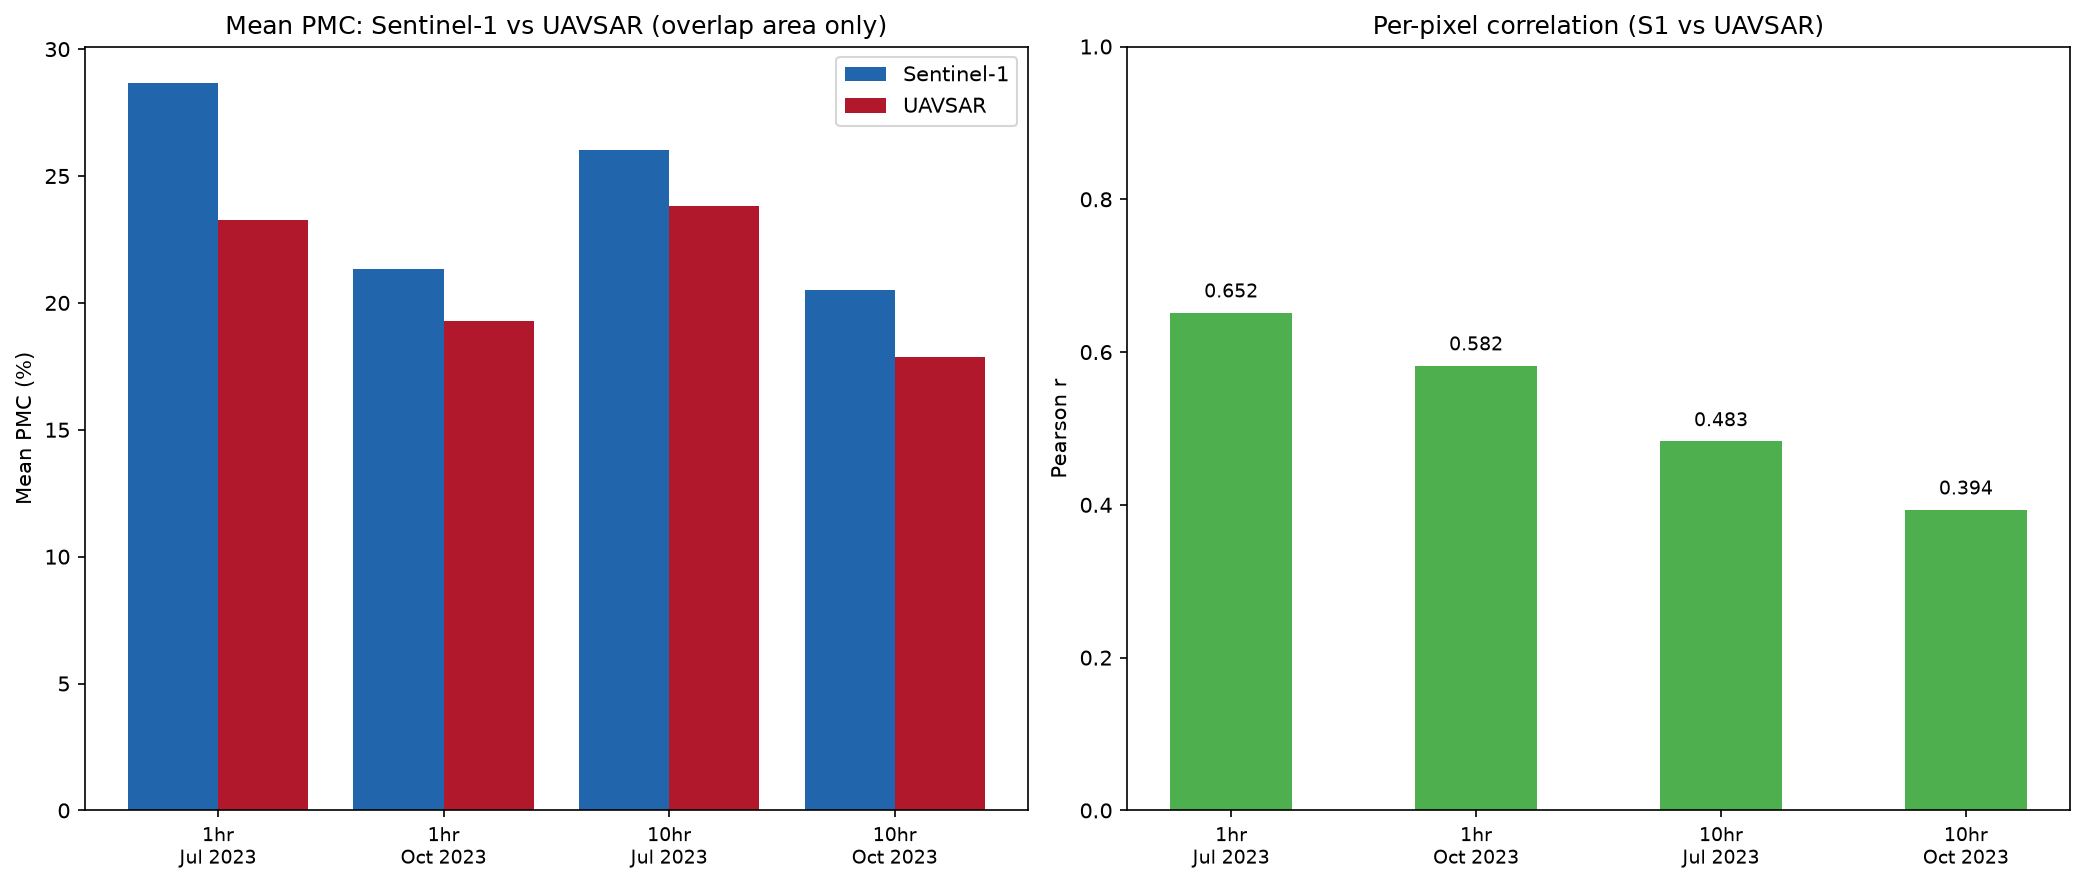

### Why they diverge — likely drivers

- **Different radar physics.** Sentinel-1 is C-band (~5.6 cm wavelength, satellite); UAVSAR is L-band (~24 cm, airborne). They penetrate and interact with vegetation at different depths and are each driven by a *separately trained* deep-learning retrieval model. The two "PMC" products are not guaranteed to be quantitatively identical even at the same pixel.
- **Spatial-scale mismatch.** UAVSAR's ~6 m pixels resolve individual shrubs and openings that Sentinel-1's 30 m pixels average together — sub-pixel mixing differences.
- **One-day date offset** (Jul: S1 28th vs UAV 27th; Oct: S1 8th vs UAV 10th). Day-to-day moisture shifts are plausible.
- **Persistent hotspot could reflect vegetation structure or topography.** The −112.0° band where divergence concentrates may correspond to denser canopy or rougher terrain where the two wavelengths respond most differently; this is worth investigating against land-cover/DEM data.
- **PMC band interpretation is partially unconfirmed** (per skill caveats). Cross-sensor magnitude comparisons should be treated cautiously until the retrieval models are documented.

### Bottom line

The two sensors tell the **same qualitative story** — fuels dried from summer into fall — but disagree on **absolute moisture by 10–14 percentage points (MAE)** on average, with Sentinel-1 systematically wetter. Agreement is moderate (r ≈ 0.4–0.65) and is best for fine fuels in summer, worst for coarse fuels in fall. If you need a single moisture number for a location, the sensor choice matters; if you only need *relative* wet/dry patterns, both sensors agree reasonably well. Full statistics saved to `sensor_agreement_stats.csv`.

In [3]:
%%ask
The area was imaged two ways: a fine-resolution airborne radar and a coarser 
satellite one. Over the part of the forest both cover, how well do their 
fuel-moisture estimates agree, and where do they diverge most?